Implementing Maher Poisson model, cross referencing against odds

In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import factorial, exp
import scipy.optimize



In [183]:
df21 = pd.read_csv("prem_21.csv")
df22 = pd.read_csv("prem_22.csv")
df23 = pd.read_csv("prem_23.csv")
df24 = pd.read_csv("prem_24.csv")

df24.insert(0, "Season", "23to24")
print(df24.head(5))

df23.insert(0, "Season", "22to23")
df22.insert(0, "Season", "21to22")
df21.insert(0, "Season", "20to21")


   Season Div        Date   Time     HomeTeam       AwayTeam  FTHG  FTAG FTR  \
0  23to24  E0  11/08/2023  20:00      Burnley       Man City     0     3   A   
1  23to24  E0  12/08/2023  12:30      Arsenal  Nott'm Forest     2     1   H   
2  23to24  E0  12/08/2023  15:00  Bournemouth       West Ham     1     1   D   
3  23to24  E0  12/08/2023  15:00     Brighton          Luton     4     1   H   
4  23to24  E0  12/08/2023  15:00      Everton         Fulham     0     1   A   

   HTHG  ...  AvgC<2.5  AHCh B365CAHH  B365CAHA  PCAHH  PCAHA  MaxCAHH  \
0     0  ...      2.28  1.50     1.95      1.98   1.95   1.97      NaN   
1     2  ...      2.63 -2.00     1.95      1.98   1.93   1.97     2.01   
2     0  ...      2.12  0.00     2.02      1.91   2.01   1.92     2.06   
3     1  ...      2.48 -1.75     2.01      1.92   2.00   1.91     2.14   
4     0  ...      1.71 -0.25     2.06      1.87   2.04   1.88     2.08   

   MaxCAHA  AvgCAHH  AvgCAHA  
0      NaN     1.92     1.95  
1     2.09  

In [184]:
df_train = pd.concat([df24, df23, df22, df21])
print(df21.shape)

# one data set to find roots from
print(df_train.shape)
print(df_train)

(380, 107)
(1520, 107)
     Season Div        Date   Time          HomeTeam        AwayTeam  FTHG  \
0    23to24  E0  11/08/2023  20:00           Burnley        Man City     0   
1    23to24  E0  12/08/2023  12:30           Arsenal   Nott'm Forest     2   
2    23to24  E0  12/08/2023  15:00       Bournemouth        West Ham     1   
3    23to24  E0  12/08/2023  15:00          Brighton           Luton     4   
4    23to24  E0  12/08/2023  15:00           Everton          Fulham     0   
..      ...  ..         ...    ...               ...             ...   ...   
375  20to21  E0  23/05/2021  16:00         Liverpool  Crystal Palace     2   
376  20to21  E0  23/05/2021  16:00          Man City         Everton     5   
377  20to21  E0  23/05/2021  16:00  Sheffield United         Burnley     1   
378  20to21  E0  23/05/2021  16:00          West Ham     Southampton     3   
379  20to21  E0  23/05/2021  16:00            Wolves      Man United     1   

     FTAG FTR  HTHG  ...  AvgC<2.5  AHCh

In [185]:
teams = sorted(list(dict.fromkeys(df_train["HomeTeam"].tolist())))
teams2 = sorted(list(dict.fromkeys(df_train["AwayTeam"].tolist())))
print(teams == teams2)

teams_dict  = {team: i for i, team in enumerate(teams)}
print(teams_dict)

scored_at_home = df_train.groupby("HomeTeam")["FTHG"].sum().tolist()
print(scored_at_home)

x_total = scored_at_home

def negative_likelihood_function(params):
    n_teams = len(teams)
    l = 0
    a_params = params[:n_teams]
    b_params = params[n_teams:2*n_teams]
    gamma = params[-1]
    for m in range(df_train.shape[0]):
            h_team = df_train["HomeTeam"].iloc[m]
            a_team = df_train["AwayTeam"].iloc[m]

            h_goals = df_train["FTHG"].iloc[m]
            a_goals = df_train["FTAG"].iloc[m]

            a_idx = teams_dict.get(h_team)
            b_idx = teams_dict.get(a_team)
            l += -gamma * a_params[a_idx] * b_params[b_idx] + h_goals * np.log(gamma * a_params[a_idx] * b_params[b_idx]) - np.log(factorial(h_goals)) -\
                a_params[b_idx] * b_params[a_idx] + a_goals* np.log(a_params[b_idx] * b_params[a_idx]) - np.log(factorial(a_goals))
    return -l

def norm_const(params):
    a_sum = 0
    for i in range(len(teams)):
        a_sum += params[i]
    return a_sum - len(teams)



initial_params = np.ones(len(teams)*2 +1)

print(initial_params)
optimised_likelihood = scipy.optimize.minimize(negative_likelihood_function, initial_params, bounds = [(1e-6, None)] * len(initial_params),constraints = {"type": "eq", "fun": norm_const})
# finds the maximisers of the likelihood, i.e. the rates that we care about






True
{'Arsenal': 0, 'Aston Villa': 1, 'Bournemouth': 2, 'Brentford': 3, 'Brighton': 4, 'Burnley': 5, 'Chelsea': 6, 'Crystal Palace': 7, 'Everton': 8, 'Fulham': 9, 'Leeds': 10, 'Leicester': 11, 'Liverpool': 12, 'Luton': 13, 'Man City': 14, 'Man United': 15, 'Newcastle': 16, 'Norwich': 17, "Nott'm Forest": 18, 'Sheffield United': 19, 'Southampton': 20, 'Tottenham': 21, 'Watford': 22, 'West Brom': 23, 'West Ham': 24, 'Wolves': 25}
[160, 139, 47, 86, 108, 51, 132, 105, 89, 71, 73, 91, 173, 28, 212, 137, 137, 12, 54, 31, 70, 148, 17, 15, 122, 86]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]


In [ ]:
coeffs = optimised_likelihood.x
success = optimised_likelihood.message
att_def_coeffs_dict = {"Team": [team for team in teams], "AttackCoefficient": [coeffs[i] for i in range(len(teams))], "DefenceCoefficient": [coeffs[i+len(teams)] for i in range(len(teams))]}
df_AD_coeffs = pd.DataFrame(att_def_coeffs_dict)
df_AD_coeffs.head(26)
# print(success)
# print(coeffs)

,Team,AttackCoefficient,DefenceCoefficient
0,Arsenal,1.405049,0.915776
1,Aston Villa,1.126658,1.175832
2,Bournemouth,0.896042,1.531891
3,Brentford,1.045711,1.254173
4,Brighton,1.005568,1.157528
5,Burnley,0.694558,1.392767
6,Chelsea,1.191173,1.020027
7,Crystal Palace,0.907324,1.230605
8,Everton,0.791861,1.240435
9,Fulham,0.884413,1.245392


In [187]:
all_games =[]
# three for loops potentially too expensive but we'll see
for m in range(df_train.shape[0]):
    game_m = []
    for x in range(10):
        game_m_score_x = []
        for y in range(10):
            gamma = coeffs[-1]
            i = df_train["HomeTeam"].iloc[m]
            j = df_train["AwayTeam"].iloc[m]

            i_a = df_AD_coeffs.loc[df_AD_coeffs["Team"] == i, "AttackCoefficient"].iloc[0]
            i_d = df_AD_coeffs.loc[df_AD_coeffs["Team"] ==i, "DefenceCoefficient"].iloc[0]

            j_a = df_AD_coeffs.loc[df_AD_coeffs["Team"] == j, "AttackCoefficient"].iloc[0]
            j_d = df_AD_coeffs.loc[df_AD_coeffs["Team"] ==j, "DefenceCoefficient"].iloc[0]

            match_outcome_prob = (((i_a * j_d * gamma) ** x)/factorial(x)) * (((j_a * i_d) ** y)/factorial(y)) * exp(-(i_a * j_d * gamma + j_a * i_d))
            game_m_score_x.append(match_outcome_prob)
        game_m.append(game_m_score_x)
    all_games.append(game_m)


        




In [188]:
print(all_games[2][7][7]) # match 2 score 7-7 obvs should be smol

5.713723356524572e-07


In [189]:
P_Win = []
P_Draw = []
for i in range(df_train.shape[0]):
    P_Win_Game_i = 0
    for j in range(10):
        for k in range(j):
            P_Win_Game_i += all_games[i][j][k]
    P_Win.append(P_Win_Game_i)

for i in range(df_train.shape[0]):
    P_Draw_Game_i = 0
    for j in range(10):
        P_Draw_Game_i += all_games[i][j][j]
    P_Draw.append(P_Draw_Game_i)


P_Loss = []
for i in range(df_train.shape[0]):
    P_Lose_Game_i = 0
    for j in range(10):
        for k in range(j+1, 10):
            P_Lose_Game_i += all_games[i][j][k]
    P_Loss.append(P_Lose_Game_i)

print(P_Win[1] + P_Draw[1] + P_Loss[1]) # should be just less than 1 if indexed properly (only counted up to 10-10)





0.9997419113318502


In [190]:
df_my_probs = pd.DataFrame({"HomeTeam": df_train["HomeTeam"], "AwayTeam": df_train["AwayTeam"],
                            "Home Prob": P_Win, "Draw Prob": P_Draw, "Away Prob": P_Loss})
print(df_my_probs.head(19))

            HomeTeam          AwayTeam  Home Prob  Draw Prob  Away Prob
0            Burnley          Man City   0.071506   0.147223   0.781034
1            Arsenal     Nott'm Forest   0.744230   0.157765   0.097747
2        Bournemouth          West Ham   0.314628   0.239204   0.446156
3           Brighton             Luton   0.621175   0.192384   0.186301
4            Everton            Fulham   0.373008   0.286513   0.340479
5   Sheffield United    Crystal Palace   0.171780   0.238933   0.589275
6          Newcastle       Aston Villa   0.428433   0.239982   0.331574
7          Brentford         Tottenham   0.336364   0.233700   0.429921
8            Chelsea         Liverpool   0.309124   0.247707   0.443162
9         Man United            Wolves   0.569939   0.240284   0.189766
10     Nott'm Forest  Sheffield United   0.625901   0.218292   0.155780
11            Fulham         Brentford   0.369527   0.263337   0.367134
12         Liverpool       Bournemouth   0.781856   0.135140   0

What were the odds of this all working try? Get it?


In [191]:
HP_imp = 1/df_train["PSH"]
DP_imp = 1/df_train["PSD"]
AP_imp = 1/df_train["PSA"]



df_implied_probs = pd.concat([df_train.loc[:, ["HomeTeam", "AwayTeam"]], HP_imp, DP_imp, AP_imp], axis = 1)
print(df_implied_probs)

home_difference_odss = np.abs(df_implied_probs["PSH"] - df_my_probs["Home Prob"])
print(home_difference_odss)

             HomeTeam        AwayTeam       PSH       PSD       PSA
0             Burnley        Man City  0.116550  0.181488  0.729927
1             Arsenal   Nott'm Forest  0.847458  0.127226  0.063816
2         Bournemouth        West Ham  0.370370  0.288184  0.369004
3            Brighton           Luton  0.751880  0.176991  0.104058
4             Everton          Fulham  0.440529  0.289855  0.298507
..                ...             ...       ...       ...       ...
375         Liverpool  Crystal Palace  0.862069  0.114548  0.054585
376          Man City         Everton  0.699301  0.196464  0.138122
377  Sheffield United         Burnley  0.348432  0.267380  0.411523
378          West Ham     Southampton  0.574713  0.250627  0.198807
379            Wolves      Man United  0.386100  0.264550  0.370370

[1520 rows x 5 columns]
0      0.045044
1      0.103228
2      0.055742
3      0.130705
4      0.067521
         ...   
375    0.168219
376    0.103143
377    0.092190
378    0.012066

Looking at Log Loss

In [192]:
loss = 0
for m in range(df_train.shape[0]):
    if df_train["FTR"].iloc[m] == "H":
        loss -= np.log(df_my_probs["Home Prob"].iloc[m])
    elif df_train["FTR"].iloc[m] == "D":
        loss -= np.log(df_my_probs["Draw Prob"].iloc[m])
    else:
        loss -= np.log(df_my_probs["Away Prob"].iloc[m])
    
print(loss/df_train.shape[0])
# 0.95, not awful, not great, but good sanity check before validation

0.9538388749831656


<u><span style="font-size: 20px">
VALIDATION
</span>


<span style = "font-size: 16px"> 1. Log Loss on Validation data </span>

In [193]:
# First get useful validation data, we use 24/25 prem

df25 = pd.read_csv("prem_25.csv")
df_valid = df25.loc[:, ["HomeTeam", "AwayTeam", "FTR", "PSH", "PSD", "PSA"]]
df_valid.head(20)
teams_validation = sorted(list(dict.fromkeys(df_valid["HomeTeam"])))

# First it's worth checking that all teams in the prem were there at some point during the training data era
promoted = []

for team in teams_validation:
    if team not in teams:
        promoted.append(team)
print(promoted) 

# Annoying. Who even rates Ipswich. We'll look at the intersection

relegated = []
for team in teams:
    if team not in teams_validation:
        relegated.append(team)

print(promoted + relegated)

df_valid2 = df_valid[~((df_valid["HomeTeam"] == "Ipswich") | (df_valid["AwayTeam"] == "Ipswich"))].reset_index(drop = True)
print(df_valid2.shape) # should expect 380 - 19*2 = 342 

# To do the log loss on validation set, we need to recompute the probabilities again for the validation set

def match_outcome_probabilities(game_data, attack_defence_coefficients, gamma,
                                Home_team_name = "HomeTeam",
                                Away_team_name = "AwayTeam",
                                Team_column_name = "Team", 
                                attack_coefficent_name = "AttackCoefficient",
                                defence_coefficient_name = "DefenceCoefficient",
                                max_goals = 10):
    all_game_probabilities = []
    coefficients_by_team = attack_defence_coefficients.set_index(Team_column_name)
    for m in range(game_data.shape[0]):
        home = game_data[Home_team_name].loc[m]
        away = game_data[Away_team_name].loc[m]

        Home_Atk = coefficients_by_team.loc[home, attack_coefficent_name]
        Home_Def = coefficients_by_team.loc[home, defence_coefficient_name]
        Away_Atk = coefficients_by_team.loc[away, attack_coefficent_name]
        Away_Def = coefficients_by_team.loc[away, defence_coefficient_name]


        match_m_probs = []
        for x in range(max_goals):
            match_m_score_x = []
            for y in range(max_goals):
                
                match_outcome_prob = (((Home_Atk * Away_Def * gamma) ** x)/factorial(x)) * (((Away_Atk * Home_Def) ** y)/factorial(y)) * exp(-(Home_Atk * Away_Def * gamma + Away_Atk * Home_Def))
                match_m_score_x.append(match_outcome_prob)
            match_m_probs.append(match_m_score_x)
        all_game_probabilities.append(match_m_probs)
    return all_game_probabilities

def HDA_probs(all_game_probabilities, HomeTeam, AwayTeam, max_goals = 10):

    # The matrix is slightly truncated (max no. goals is 10) probabilities will add to less than one, so will need to normalise
    home_unnorm = []
    draw_unnorm = []
    away_unnorm =[]

    home = []
    draw = []
    away = []

    for m in range(len(all_game_probabilities)):
        h = 0
        d = 0
        a = 0
        for i in range(max_goals):
            # All scores where no. goals equal 
            d += all_game_probabilities[m][i][i]

            # Home team wins are on the lower diagonal
            for j in range(i):
                h += all_game_probabilities[m][i][j]

            for k in range(i+1, max_goals):
                a += all_game_probabilities[m][i][k]

        home_unnorm.append(h)
        draw_unnorm.append(d)
        away_unnorm.append(a)

    for l in range(len(all_game_probabilities)):
        total_prob = home_unnorm[l] + draw_unnorm[l] + away_unnorm[l]
        home.append(home_unnorm[l]/total_prob)
        draw.append(draw_unnorm[l]/total_prob)
        away.append(away_unnorm[l]/total_prob)
    
    df_HDA = pd.DataFrame({"HomeTeam": HomeTeam, "AwayTeam": AwayTeam, "Home": home, "Draw": draw, "Away": away})

    return df_HDA
        



['Ipswich']
['Ipswich', 'Burnley', 'Leeds', 'Luton', 'Norwich', 'Sheffield United', 'Watford', 'West Brom']
(342, 6)


In [194]:
# Testing the match outcome function
games = match_outcome_probabilities(df_valid2, df_AD_coeffs, coeffs[-1])
print(games[17][2][3])
            

0.014573605818237252


In [ ]:
# Testing the HDA_probs function
df_HDA = HDA_probs(games, df_valid2["HomeTeam"], df_valid2["AwayTeam"])
print(df_HDA)

          HomeTeam     AwayTeam      Home      Draw      Away
0       Man United       Fulham  0.540848  0.237419  0.221732
1          Arsenal       Wolves  0.685999  0.197538  0.116463
2          Everton     Brighton  0.318817  0.280424  0.400759
3        Newcastle  Southampton  0.628552  0.199686  0.171762
4    Nott'm Forest  Bournemouth  0.422119  0.247075  0.330807
..             ...          ...       ...       ...       ...
337      Newcastle      Everton  0.544817  0.238629  0.216554
338  Nott'm Forest      Chelsea  0.217055  0.232602  0.550342
339    Southampton      Arsenal  0.141262  0.191163  0.667575
340      Tottenham     Brighton  0.523738  0.227592  0.248670
341         Wolves    Brentford  0.321111  0.277049  0.401841

[342 rows x 5 columns]


In [196]:
print(df_valid2.shape[0])

342


In [197]:
# Make log lossfunction for later use

def log_loss(df_market, df_model):
    log_loss = 0
    n_matches = df_market.shape[0]
    for i in range(n_matches):
        if df_market["FTR"].iloc[i] == "H":
            log_loss -= np.log(df_model["Home"].loc[i])
        elif df_market["FTR"].iloc[i] == "D":
            log_loss -= np.log(df_model["Draw"].loc[i])
        else: 
            log_loss -= np.log(df_model["Away"].loc[i])
    return log_loss / n_matches


In [ ]:
#Log Loss on validation data
log_loss(df_valid2, df_HDA)

# Awful, at least it motivates Dixon-Coles

np.float64(1.040379056748952)

<span style = "font-size: 16px"> 2. Brier Score on Validation data </span>

In [199]:
def brier_score(df_market, df_model, outcome_list = ["H", "D", "A"], Home_col_name = "Home", Draw_col_name = "Draw", Away_col_name = "Away"):
    Brier_Scores = []
    for m in range(df_market.shape[0]):
        v_market = np.array([int(df_market["FTR"].iloc[m] == i) for i in outcome_list])
        v_prob = np.array([df_model[Home_col_name].iloc[m], df_model[Draw_col_name].iloc[m], df_model[Away_col_name].iloc[m]])

        Brier_Scores.append(np.linalg.norm(v_market - v_prob)**2)
    Brier_Score = np.mean(np.array(Brier_Scores))
    
    return Brier_Score




In [318]:
brier_score(df_valid2, df_HDA)

np.float64(0.6266795265853192)

<span style = "font-size: 16px"> 3. Calibration Curve </span>

/var/folders/5w/3d7_1yz55cd3w_l664lgmqdw0000gn/T/ipykernel_1011/1681933510.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_tracker["H"] = home_win.groupby(binsH).mean().sort_index()
/var/folders/5w/3d7_1yz55cd3w_l664lgmqdw0000gn/T/ipykernel_1011/1681933510.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_tracker["D"] = draw.groupby(binsD).mean().sort_index()
/var/folders/5w/3d7_1yz55cd3w_l664lgmqdw0000gn/T/ipykernel_1011/1681933510.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain cu

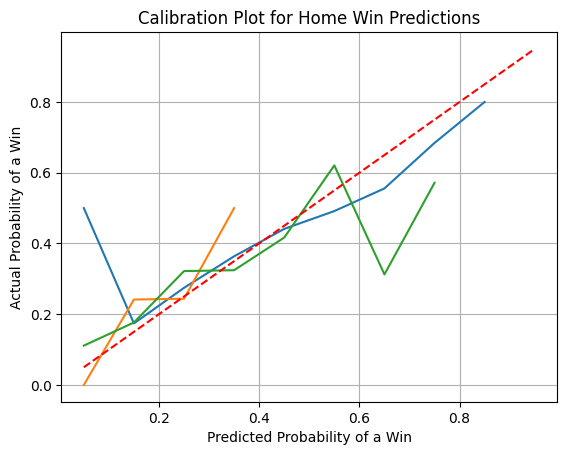

In [220]:
def calibration_curve(df_market, df_model, Home_prob_name = "Home", Draw_prob_name = "Draw", Away_prob_name = "Away"):
    bins = list(np.linspace(0.0, 1, 11))

    result_tracker = pd.DataFrame({})

    binsH = pd.cut(df_model[Home_prob_name], bins)
    binsD = pd.cut(df_model[Draw_prob_name], bins)
    binsA = pd.cut(df_model[Away_prob_name], bins)
    
    home_win = (df_market["FTR"] == "H").astype(int)
    draw = (df_market["FTR"] == "D").astype(int)
    away_win = (df_market["FTR"] == "A").astype(int)

    result_tracker["H"] = home_win.groupby(binsH).mean().sort_index()
    result_tracker["D"] = draw.groupby(binsD).mean().sort_index()
    result_tracker["A"] = away_win.groupby(binsA).mean()

    x = np.linspace(0.05, 0.95, 10)
    plt.plot(x, np.array(result_tracker["H"]))
    plt.plot(x, np.array(result_tracker["D"]))
    plt.plot(x, np.array(result_tracker["A"]))
    plt.plot(x, x, color = "red", linestyle = "--")

    plt.xlabel("Predicted Probability of a Win")
    plt.ylabel("Actual Probability of a Win")
    plt.title("Calibration Plot for Home Win Predictions")
    plt.grid(True)


calibration_curve(df_valid2, df_HDA)




<span style = "font-size: 16px"> 4. Betting Strategies </span>

<span style = "font-size: 12px"> 4i. Betting Strategy A: Fixed bet size beyond a threshold </span>

In [ ]:
print(df_valid2.head(10), df_HDA.head(10))

        HomeTeam        AwayTeam FTR   PSH   PSD    PSA
0     Man United          Fulham   H  1.63  4.38   5.30
1        Arsenal          Wolves   H  1.16  8.56  16.22
2        Everton        Brighton   A  2.73  3.36   2.71
3      Newcastle     Southampton   H  1.35  5.70   8.25
4  Nott'm Forest     Bournemouth   D  2.47  3.42   2.97
5       West Ham     Aston Villa   A  2.49  3.65   2.80
6      Brentford  Crystal Palace   H  2.50  3.40   2.95
7        Chelsea        Man City   A  4.19  3.93   1.84
8      Leicester       Tottenham   D  5.09  4.39   1.63
9       Brighton      Man United   H  2.51  3.66   2.76         HomeTeam        AwayTeam      Home      Draw      Away
0     Man United          Fulham  0.540848  0.237419  0.221732
1        Arsenal          Wolves  0.685999  0.197538  0.116463
2        Everton        Brighton  0.318817  0.280424  0.400759
3      Newcastle     Southampton  0.628552  0.199686  0.171762
4  Nott'm Forest     Bournemouth  0.422119  0.247075  0.330807
5     

In [283]:
def betting_strategy_a(df_market, df_model, tolerance_percentage = 75, home_market_odds = "PSH", draw_market_odds = "PSD", away_market_odds = "PSA",
                    home_prob_col = "Home", draw_prob_col = "Draw", away_prob_col = "Away", result_col_name = "FTR"):
    profit = 0
    df_ev = pd.DataFrame({})

    df_ev["Home_EV"] = df_market[home_market_odds] * df_model[home_prob_col] -1
    df_ev["Draw_EV"] = df_market[draw_market_odds] * df_model[draw_prob_col] -1
    df_ev["Away_EV"] = df_market[away_market_odds] * df_model[away_prob_col] -1

    for m in range(df_market.shape[0]):
        if df_ev["Home_EV"].iloc[m] > (tolerance_percentage / 100):
            profit += (df_market[home_market_odds].iloc[m] * int(df_market[result_col_name].iloc[m] == "H")) - 1
        
        if df_ev["Draw_EV"].iloc[m] > (tolerance_percentage / 100):
            profit += (df_market[draw_market_odds].iloc[m] * int(df_market[result_col_name].iloc[m] == "D")) - 1

        if df_ev["Away_EV"].iloc[m] > (tolerance_percentage / 100):
            profit += (df_market[away_market_odds].iloc[m] * int(df_market[result_col_name].iloc[m] == "A")) - 1
    
    return profit

print(betting_strategy_a(df_valid2, df_HDA))


-9.299999999999999


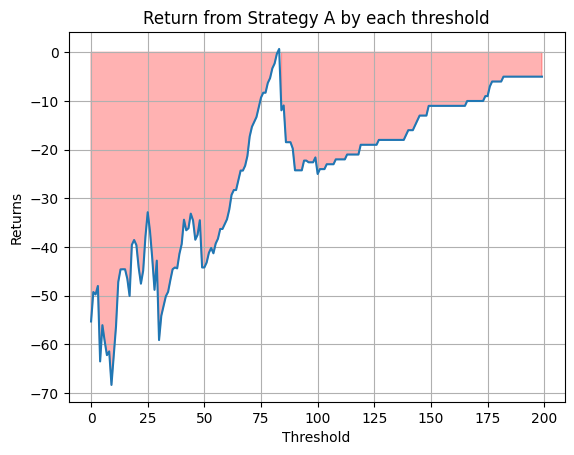

In [297]:
strategy_a_returns =[]
for i in range(200):
    profit= betting_strategy_a(df_valid2, df_HDA, i)
    strategy_a_returns.append(profit)
x_a = np.linspace(0, 199, 200)
plt.plot(x, strategy_a_returns)
plt.title("Return from Strategy A by each threshold")
plt.xlabel("Threshold")
plt.ylabel("Returns")
plt.grid()
plt.fill_between(x_a, strategy_a_returns, 0, where=(np.array(strategy_a_returns) > 0), color="green", alpha=0.3)
plt.fill_between(x_a, strategy_a_returns, 0, where=(np.array(strategy_a_returns) <= 0), color="red", alpha=0.3)


<span style = "font-size: 12px"> 4ii. Betting Strategy B: Scale the bet by the size of the deviation </span>

In [285]:
def betting_strategy_b(df_market, df_model, home_market_odds = "PSH", draw_market_odds = "PSD", away_market_odds = "PSA",
                    home_prob_col = "Home", draw_prob_col = "Draw", away_prob_col = "Away", result_col_name = "FTR"):
    profit = 0
    df_ev = pd.DataFrame({})

    df_ev["Home_EV"] = df_market[home_market_odds] * df_model[home_prob_col] -1
    df_ev["Draw_EV"] = df_market[draw_market_odds] * df_model[draw_prob_col] -1
    df_ev["Away_EV"] = df_market[away_market_odds] * df_model[away_prob_col] -1

    for m in range(df_market.shape[0]):
        if df_ev["Home_EV"].iloc[m] > 0:
            profit += (df_market[home_market_odds].iloc[m] * int(df_market[result_col_name].iloc[m] == "H")) * df_ev["Home_EV"].iloc[m] - df_ev["Home_EV"].iloc[m]
        
        if df_ev["Draw_EV"].iloc[m] > 0:
            profit += (df_market[draw_market_odds].iloc[m] * int(df_market[result_col_name].iloc[m] == "D")) * df_ev["Draw_EV"].iloc[m] - df_ev["Draw_EV"].iloc[m]

        if df_ev["Away_EV"].iloc[m] > 0:
            profit += (df_market[away_market_odds].iloc[m] * int(df_market[result_col_name].iloc[m] == "A")) * df_ev["Away_EV"].iloc[m] - df_ev["Away_EV"].iloc[m]
    
    return profit

In [286]:
print(betting_strategy_b(df_valid2, df_HDA))

-51.3660738875047


<span style = "font-size: 12px"> 4iii. Betting Strategy C: Scale the bet by the size of the deviation and bet only when above a threshold (combination of both previous strategies) </span>


In [295]:
def betting_strategy_c(df_market, df_model, tolerance_percentage = 75, home_market_odds = "PSH", draw_market_odds = "PSD", away_market_odds = "PSA",
                    home_prob_col = "Home", draw_prob_col = "Draw", away_prob_col = "Away", result_col_name = "FTR"):
    profit = 0
    df_ev = pd.DataFrame({})

    df_ev["Home_EV"] = df_market[home_market_odds] * df_model[home_prob_col] -1
    df_ev["Draw_EV"] = df_market[draw_market_odds] * df_model[draw_prob_col] -1
    df_ev["Away_EV"] = df_market[away_market_odds] * df_model[away_prob_col] -1

    for m in range(df_market.shape[0]):
        if df_ev["Home_EV"].iloc[m] > (tolerance_percentage / 100):
            profit += ((df_market[home_market_odds].iloc[m] * int(df_market[result_col_name].iloc[m] == "H")) - 1) * df_ev["Home_EV"].iloc[m]
        
        if df_ev["Draw_EV"].iloc[m] > (tolerance_percentage / 100):
            profit += ((df_market[draw_market_odds].iloc[m] * int(df_market[result_col_name].iloc[m] == "D")) - 1) * df_ev["Draw_EV"].iloc[m]

        if df_ev["Away_EV"].iloc[m] > (tolerance_percentage / 100):
            profit += ((df_market[away_market_odds].iloc[m] * int(df_market[result_col_name].iloc[m] == "A")) - 1) * df_ev["Away_EV"].iloc[m]
            
    
    return profit

print(betting_strategy_c(df_valid2, df_HDA))

-27.877214722255026


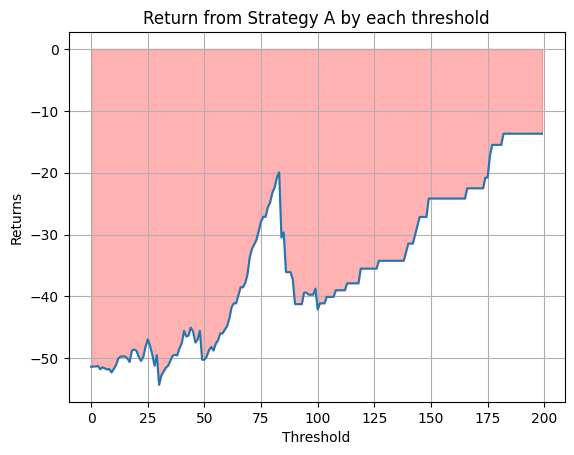

In [ ]:
strategy_c_returns =[]
for i in range(200):
    profit= betting_strategy_c(df_valid2, df_HDA, i)
    strategy_c_returns.append(profit)
x_c = np.linspace(0, 199, 200)
plt.plot(x, strategy_c_returns)
plt.title("Return from Strategy A by each threshold")
plt.xlabel("Threshold")
plt.ylabel("Returns")
plt.grid()
plt.fill_between(x_c, strategy_c_returns, 0, where=(np.array(strategy_c_returns) > 0), color="green", alpha=0.3)
plt.fill_between(x_c, strategy_c_returns, 0, where=(np.array(strategy_c_returns) <= 0), color="red", alpha=0.3)

<span style = "font-size: 16px"> 5. Conclusions on Validation </span>

• Raw Maher beats uniform randomness on both log loss and Brier $\newline$
• Significantly underperforms market on all 3 strategies $\newline$
• Strategy A best $\newline$
• Most profitable (loses the least) at around a EV threshold of 75%. $\newline$
• It is likely then that there is a lot of noise giving otherwise incorrect signals at lower thresholds

<span style = "font-size: 16px"> 6. Test </span>

In [ ]:
df_26 = pd.read_csv("prem_26.csv")
df_test = df_26.loc[:, ["HomeTeam", "AwayTeam", "FTR", "PSH", "PSD", "PSA"]]

# Must check for "Ipswich Problem" as we had in the validation set

test_teams = sorted(list(dict.fromkeys(df_test["HomeTeam"])))
promoted = []

for team in test_teams:
    if team not in teams:
        promoted.append(team)

print(promoted)


['Sunderland']


In [ ]:
df_test2 = df_test[~((df_test["HomeTeam"].isin(promoted)) | (df_test["AwayTeam"].isin(promoted)))].reset_index(drop = True)

print(df_test2["HomeTeam"].shape[0])


342


In [317]:
# Testing using previously defined functions

games_test_set = match_outcome_probabilities(df_test2, df_AD_coeffs, coeffs[-1])
df_hda_test_set = HDA_probs(games_test_set, df_test2["HomeTeam"], df_test2["AwayTeam"])
log_loss_test = log_loss(df_test2, df_hda_test_set)
brier_test_set = brier_score(df_test2, df_hda_test_set)

print("Log loss on 25/26 prem data is: ", log_loss_test, " Brier Score is: ", brier_test_set)

Log loss on 25/26 prem data is:  1.041958285224342  Brier Score is:  0.6266449514593614


/var/folders/5w/3d7_1yz55cd3w_l664lgmqdw0000gn/T/ipykernel_1011/1681933510.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_tracker["H"] = home_win.groupby(binsH).mean().sort_index()
/var/folders/5w/3d7_1yz55cd3w_l664lgmqdw0000gn/T/ipykernel_1011/1681933510.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_tracker["D"] = draw.groupby(binsD).mean().sort_index()
/var/folders/5w/3d7_1yz55cd3w_l664lgmqdw0000gn/T/ipykernel_1011/1681933510.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain cu

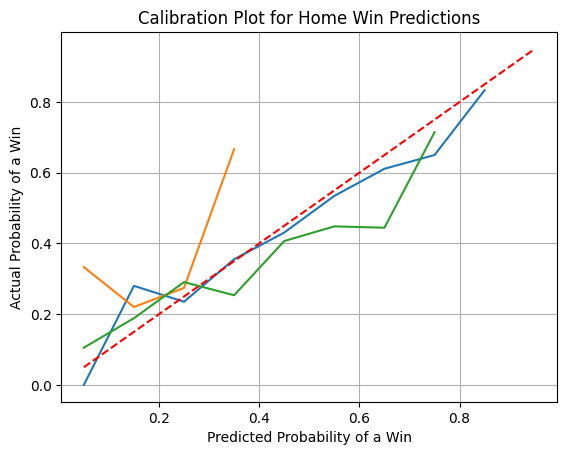

In [319]:
calibration_curve(df_test2, df_hda_test_set)

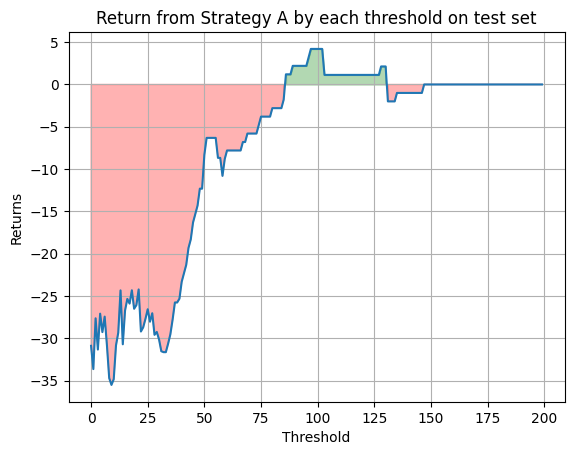

In [327]:
strategy_a_returns_test =[]
for i in range(200):
    profit = betting_strategy_a(df_test2, df_hda_test_set, i)
    strategy_a_returns_test.append(profit)
x_a_test = np.linspace(0, 199, 200)
plt.plot(x_a_test, strategy_a_returns_test)
plt.title("Return from Strategy A by each threshold on test set")
plt.xlabel("Threshold")
plt.ylabel("Returns")
plt.grid()
plt.fill_between(x_a_test, strategy_a_returns_test, 0, where=(np.array(strategy_a_returns_test) > 0), color="green", alpha=0.3)
plt.fill_between(x_a_test, strategy_a_returns_test, 0, where=(np.array(strategy_a_returns_test) <= 0), color="red", alpha=0.3)

Test Conclusions: $\newline$
$\newline$
• Log Loss and Brier score same as validation $\newline$
• Again, both better than uniform noise, but still not close to market oddds
